<a href="https://colab.research.google.com/github/dhirajpatil96/Explainable_AI_Heart_Disease_Prediction/blob/main/Explainable_AI_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Load the UCI Heart Disease dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# Cell 3: Inspect the dataset

print("Dataset Information:")
print("-" * 50)

df.info()

print("\nMissing values in each column:")
print("-" * 50)

print(df.isnull().sum())

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing values in each column:
--------------------------------------------------
age         0
sex         0
cp          0
trestbps    0
chol    

In [ ]:
# Cell 4: Statistical summary and duplicate check

print("Statistical Summary")
print("-" * 50)

display(df.describe())

print("\nNumber of duplicate rows:")
print("-" * 50)

print(df.duplicated().sum())

Statistical Summary
--------------------------------------------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



Number of duplicate rows:
--------------------------------------------------
0


In [ ]:
# Cell 5: Analyze the target variable

print("Original target variable distribution:")
print("-" * 50)

print(df["num"].value_counts().sort_index())

print("\nTarget variable percentages:")
print("-" * 50)

print((df["num"].value_counts(normalize=True).sort_index() * 100).round(2))

Original target variable distribution:
--------------------------------------------------
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target variable percentages:
--------------------------------------------------
num
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: proportion, dtype: float64


In [ ]:
# Cell 6: Convert target into binary classification

df["target"] = (df["num"] > 0).astype(int)

print("Binary target distribution:")
print("-" * 50)

print(df["target"].value_counts().sort_index())

print("\nBinary target percentages:")
print("-" * 50)

print((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

Binary target distribution:
--------------------------------------------------
target
0    164
1    139
Name: count, dtype: int64

Binary target percentages:
--------------------------------------------------
target
0    54.13
1    45.87
Name: proportion, dtype: float64


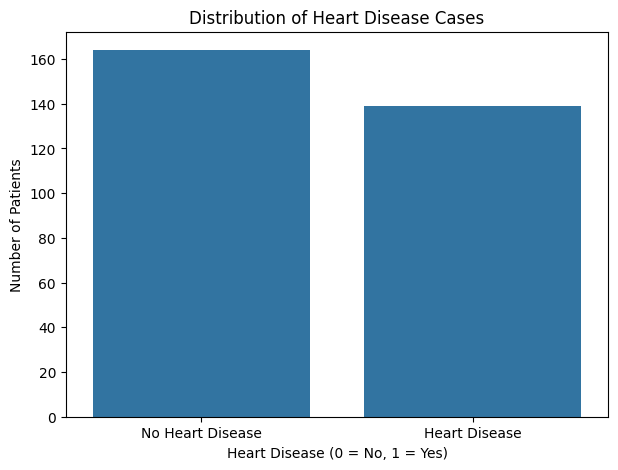

In [ ]:
# Cell 7: Visualize target distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="target")

plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])

plt.show()

In [ ]:
# Cell 8: Feature descriptions

feature_description = {
    "age": "Age in years",
    "sex": "Sex (1 = male, 0 = female)",
    "cp": "Chest pain type",
    "trestbps": "Resting blood pressure",
    "chol": "Serum cholesterol",
    "fbs": "Fasting blood sugar > 120 mg/dl",
    "restecg": "Resting electrocardiographic results",
    "thalach": "Maximum heart rate achieved",
    "exang": "Exercise-induced angina",
    "oldpeak": "ST depression induced by exercise",
    "slope": "Slope of the peak exercise ST segment",
    "ca": "Number of major vessels",
    "thal": "Thalassemia",
    "num": "Original heart disease diagnosis",
    "target": "Binary heart disease target"
}

for feature, description in feature_description.items():
    print(f"{feature:10} : {description}")

age        : Age in years
sex        : Sex (1 = male, 0 = female)
cp         : Chest pain type
trestbps   : Resting blood pressure
chol       : Serum cholesterol
fbs        : Fasting blood sugar > 120 mg/dl
restecg    : Resting electrocardiographic results
thalach    : Maximum heart rate achieved
exang      : Exercise-induced angina
oldpeak    : ST depression induced by exercise
slope      : Slope of the peak exercise ST segment
ca         : Number of major vessels
thal       : Thalassemia
num        : Original heart disease diagnosis
target     : Binary heart disease target


In [ ]:
# Cell 9: Inspect missing values

missing = df[df["ca"].isna() | df["thal"].isna()]

print("Rows containing missing values:")
print("-" * 50)

display(missing)

print("\nMissing values:")
print("-" * 50)

print(df[["ca", "thal"]].isnull().sum())

Rows containing missing values:
--------------------------------------------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0,0



Missing values:
--------------------------------------------------
ca      4
thal    2
dtype: int64


In [ ]:
# Cell 10: Separate features and target

# Remove the original target variable "num"
# Keep only the binary target that we created
X = df.drop(columns=["num", "target"])

y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (303, 13)
Target shape: (303,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [ ]:
# Cell 11: Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set:
X_train: (242, 13)
y_train: (242,)

Testing set:
X_test: (61, 13)
y_test: (61,)

Training target distribution:
target
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
target
0    33
1    28
Name: count, dtype: int64


In [ ]:
# Cell 12: Handle missing values using training-data imputation

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values before imputation:")
print("Training set:", X_train.isnull().sum().sum())
print("Testing set:", X_test.isnull().sum().sum())

print("\nMissing values after imputation:")
print("Training set:", np.isnan(X_train_imputed).sum())
print("Testing set:", np.isnan(X_test_imputed).sum())

print("\nTraining data shape:", X_train_imputed.shape)
print("Testing data shape:", X_test_imputed.shape)

Missing values before imputation:
Training set: 2
Testing set: 4

Missing values after imputation:
Training set: 0
Testing set: 0

Training data shape: (242, 13)
Testing data shape: (61, 13)


In [ ]:
# Cell 13: Standardize the features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nMean of first feature after scaling:",
      round(X_train_scaled[:, 0].mean(), 4))

print("Standard deviation of first feature after scaling:",
      round(X_train_scaled[:, 0].std(), 4))

Training data shape: (242, 13)
Testing data shape: (61, 13)

Mean of first feature after scaling: -0.0
Standard deviation of first feature after scaling: 1.0


In [ ]:
# Cell 14: Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")
print("Number of test predictions:", len(y_pred_lr))

Logistic Regression model trained successfully!
Number of test predictions: 61


In [ ]:
# Cell 15: Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("-" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print("-" * 50)

print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print("-" * 50)

print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------------------------
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1-score : 0.8667
ROC-AUC  : 0.9513

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Confusion Matrix
--------------------------------------------------
[[27  6]
 [ 2 26]]


In [ ]:
# Cell 16: Train Decision Tree model

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train_imputed, y_train)

# Predictions
y_pred_dt = decision_tree.predict(X_test_imputed)
y_prob_dt = decision_tree.predict_proba(X_test_imputed)[:, 1]

print("Decision Tree model trained successfully!")
print("Number of test predictions:", len(y_pred_dt))

Decision Tree model trained successfully!
Number of test predictions: 61


In [ ]:
# Cell 17: Evaluate Decision Tree

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("-" * 50)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

print("\nClassification Report")
print("-" * 50)

print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print("-" * 50)

print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Performance
--------------------------------------------------
Accuracy : 0.7869
Precision: 0.7273
Recall   : 0.8571
F1-score : 0.7869
ROC-AUC  : 0.8047

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61


Confusion Matrix
--------------------------------------------------
[[24  9]
 [ 4 24]]


In [ ]:
# Cell 18: Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

random_forest.fit(X_train_imputed, y_train)

# Predictions
y_pred_rf = random_forest.predict(X_test_imputed)
y_prob_rf = random_forest.predict_proba(X_test_imputed)[:, 1]

print("Random Forest model trained successfully!")
print("Number of test predictions:", len(y_pred_rf))

Random Forest model trained successfully!
Number of test predictions: 61


In [ ]:
# Cell 19: Evaluate Random Forest model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Print results
print("Random Forest Performance")
print("--------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Performance
--------------------------
Accuracy  : 0.9016
Precision : 0.8667
Recall    : 0.9286
F1 Score  : 0.8966
ROC-AUC   : 0.9578

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Confusion Matrix:
[[29  4]
 [ 2 26]]


In [ ]:
# Cell 20: Train XGBoost model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_imputed, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_imputed)
y_prob_xgb = xgb_model.predict_proba(X_test_imputed)[:, 1]

print("XGBoost model trained successfully!")
print("Number of test predictions:", len(y_pred_xgb))

XGBoost model trained successfully!
Number of test predictions: 61


In [ ]:
# Cell 21: Evaluate XGBoost model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Print results
print("XGBoost Performance")
print("--------------------")
print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Performance
--------------------
Accuracy  : 0.8361
Precision : 0.7647
Recall    : 0.9286
F1 Score  : 0.8387
ROC-AUC   : 0.9297

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83        33
           1       0.76      0.93      0.84        28

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61

Confusion Matrix:
[[25  8]
 [ 2 26]]


In [ ]:
# Cell 22: Compare all machine learning models

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_rf,
        roc_auc_xgb
    ]
})

# Convert metrics to percentage
results_percent = results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_percent[metric_columns] = (
    results_percent[metric_columns] * 100
).round(2)

print("Model Performance Comparison")
print("============================")
display(results_percent)

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,86.89,81.25,92.86,86.67,95.13
1,Decision Tree,78.69,72.73,85.71,78.69,80.47
2,Random Forest,90.16,86.67,92.86,89.66,95.78
3,XGBoost,83.61,76.47,92.86,83.87,92.97


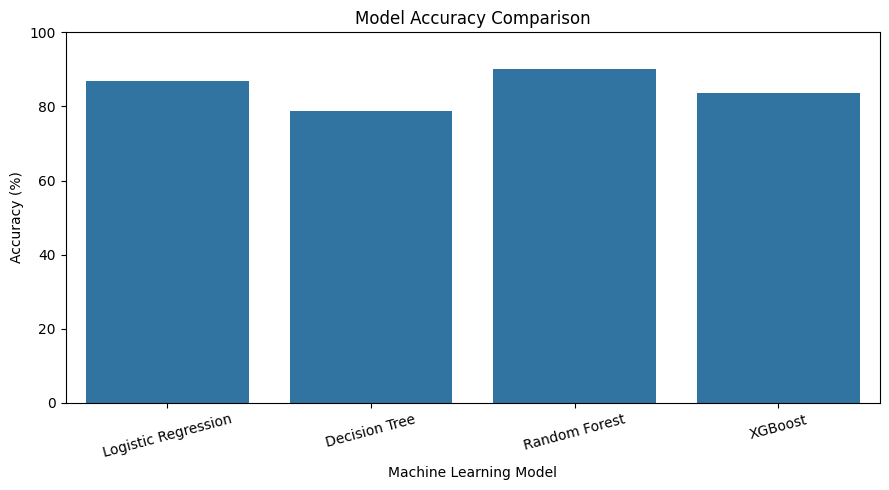

In [ ]:
# Cell 23: Visualize model accuracy

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_percent,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

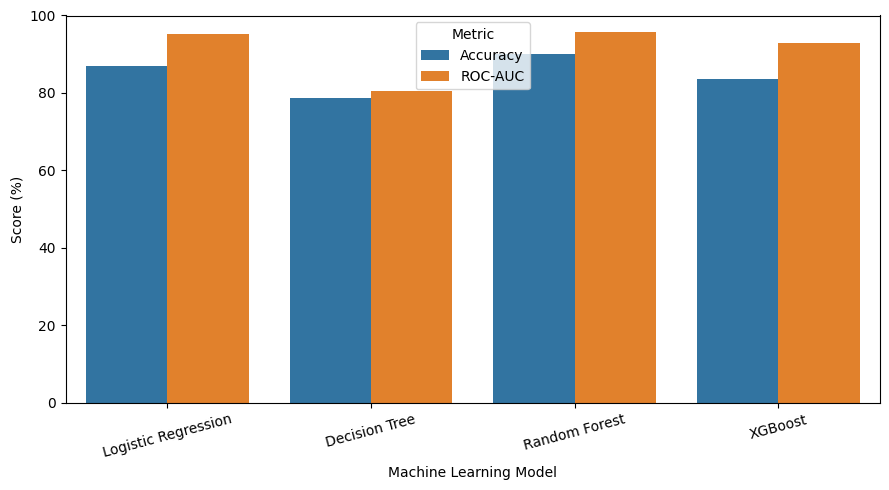

In [ ]:
# Figure 2: Model Performance Comparison

import matplotlib.pyplot as plt
import seaborn as sns

plot_data = results_percent.melt(
    id_vars="Model",
    value_vars=["Accuracy", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

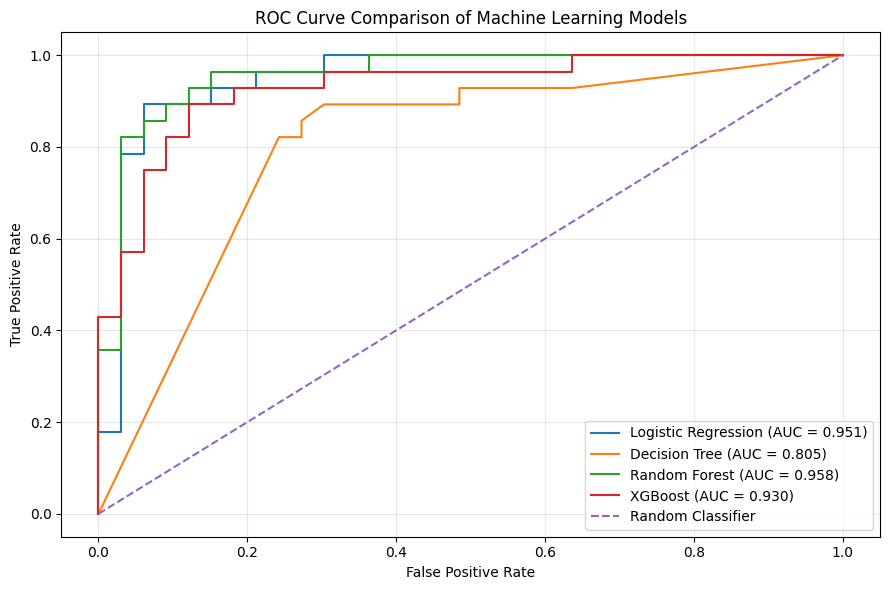

In [ ]:
# Cell 24: Plot ROC curves for all models

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Calculate AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(9, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random classifier reference
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

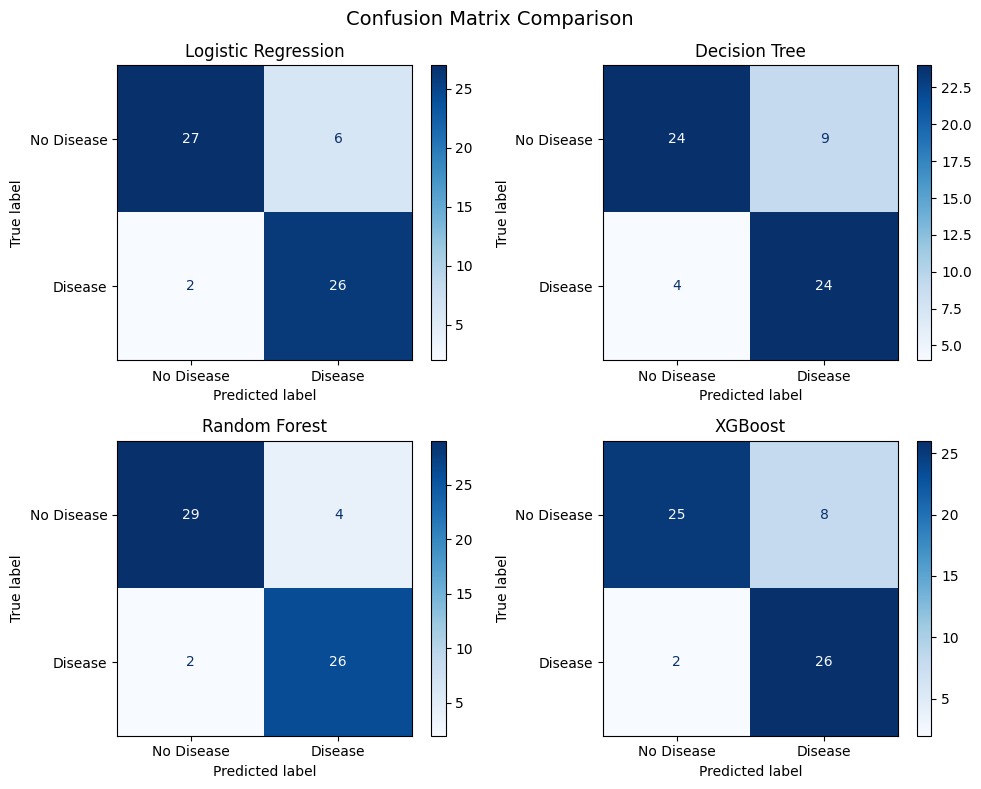

In [ ]:
# Cell 25: Confusion matrices for all models

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for ax, (name, predictions) in zip(axes.ravel(), models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No Disease", "Disease"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 26: Import SHAP

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# Cell 27: Create SHAP TreeExplainer

import shap

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(random_forest)

# Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test_imputed)

print("SHAP analysis completed successfully!")
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", getattr(shap_values, "shape", "List"))

SHAP analysis completed successfully!
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (61, 13, 2)


In [ ]:
# Cell 28: Extract SHAP values for the heart disease class

# Select SHAP values corresponding to class 1 (heart disease)
shap_values_class1 = shap_values[:, :, 1]

print("SHAP values for heart disease class:")
print("Shape:", shap_values_class1.shape)

print("\nNumber of test samples:", shap_values_class1.shape[0])
print("Number of features:", shap_values_class1.shape[1])

SHAP values for heart disease class:
Shape: (61, 13)

Number of test samples: 61
Number of features: 13


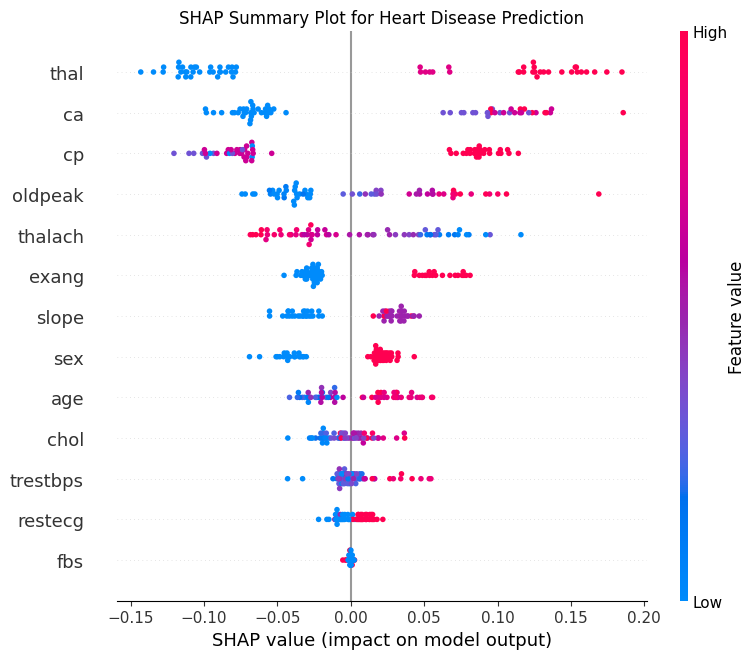

In [ ]:
# Cell 29: SHAP Summary Plot

import matplotlib.pyplot as plt

# Convert test data to DataFrame for readable feature names
X_test_imputed_df = pd.DataFrame(
    X_test_imputed,
    columns=X.columns
)

# Generate SHAP summary plot
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_class1,
    X_test_imputed_df,
    show=False
)

plt.title("SHAP Summary Plot for Heart Disease Prediction")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 30: Calculate SHAP feature importance

import numpy as np
import pandas as pd

# Calculate mean absolute SHAP value for each feature
shap_importance = np.abs(shap_values_class1).mean(axis=0)

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_Absolute_SHAP": shap_importance
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("SHAP Feature Importance")
print("=======================")
display(feature_importance)

SHAP Feature Importance


,Feature,Mean_Absolute_SHAP
0,thal,0.111091
1,ca,0.087362
2,cp,0.084572
3,oldpeak,0.048784
4,thalach,0.044427
5,exang,0.038221
6,slope,0.032532
7,sex,0.028937
8,age,0.026219
9,chol,0.013239


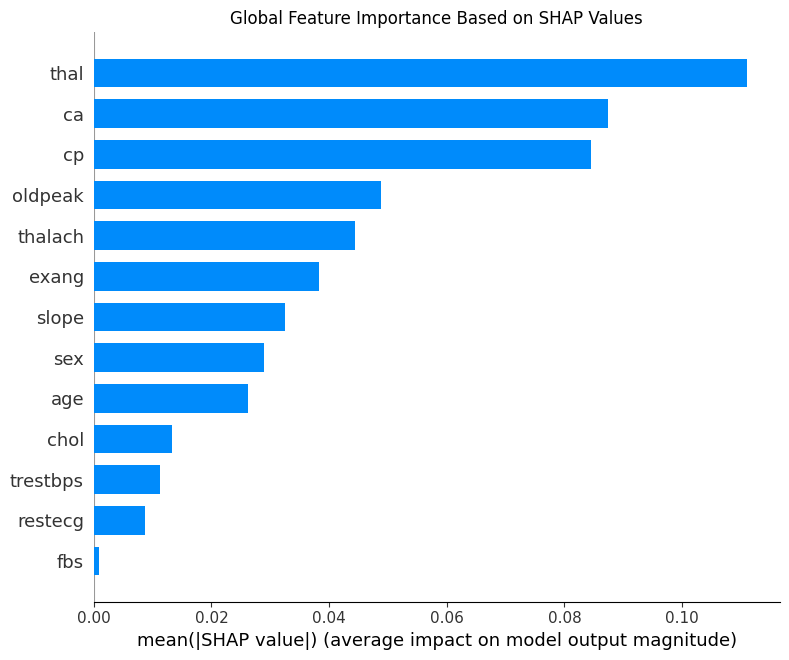

In [ ]:
# Cell 31: SHAP Global Feature Importance Bar Plot

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_class1,
    X_test_imputed_df,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance Based on SHAP Values")
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

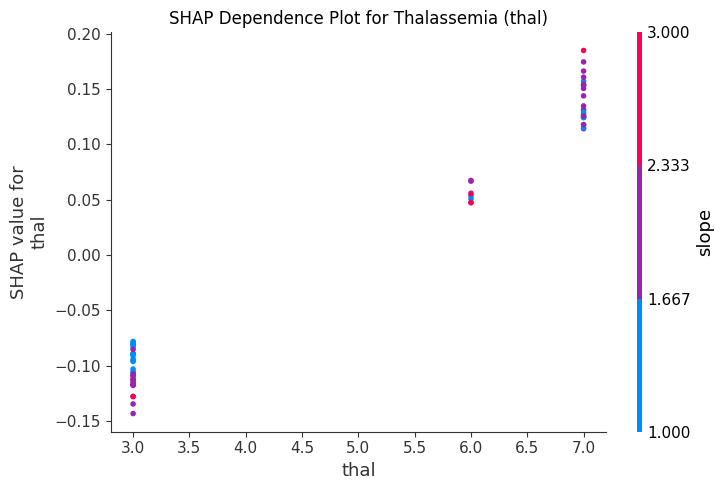

In [ ]:
# Cell 32: SHAP Dependence Plot for thal

plt.figure(figsize=(9, 6))

shap.dependence_plot(
    "thal",
    shap_values_class1,
    X_test_imputed_df,
    show=False
)

plt.title("SHAP Dependence Plot for Thalassemia (thal)")
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

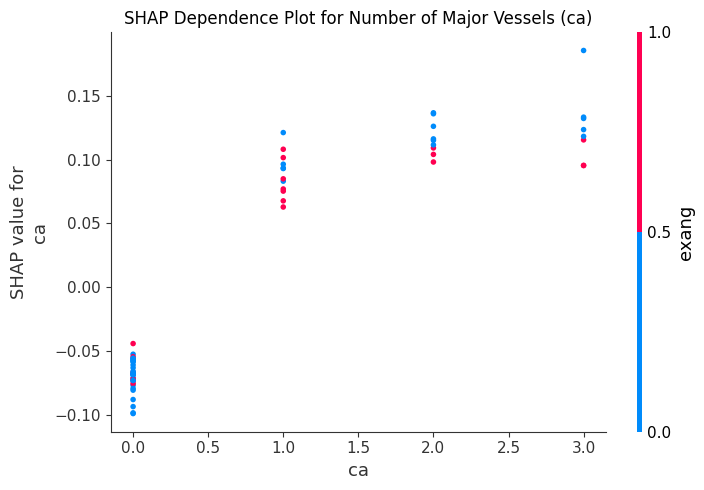

In [ ]:
# Cell 33: SHAP Dependence Plot for ca

plt.figure(figsize=(9, 6))

shap.dependence_plot(
    "ca",
    shap_values_class1,
    X_test_imputed_df,
    show=False
)

plt.title("SHAP Dependence Plot for Number of Major Vessels (ca)")
plt.tight_layout()
plt.show()


<Figure size 900x600 with 0 Axes>

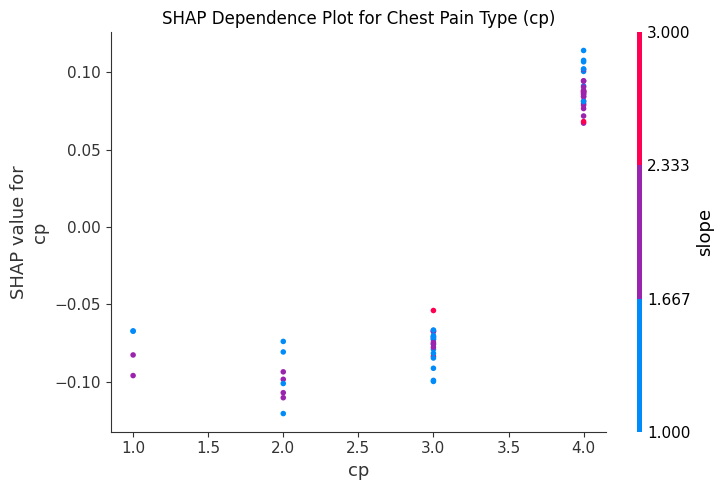

In [ ]:
# Cell 34: SHAP Dependence Plot for cp

plt.figure(figsize=(9, 6))

shap.dependence_plot(
    "cp",
    shap_values_class1,
    X_test_imputed_df,
    show=False
)

plt.title("SHAP Dependence Plot for Chest Pain Type (cp)")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 35: Select a test patient for local SHAP explanation

# Select the first patient from the test set
sample_index = 0

sample = X_test_imputed_df.iloc[[sample_index]]
actual_class = y_test.iloc[sample_index]
predicted_class = y_pred_rf[sample_index]
predicted_probability = y_prob_rf[sample_index]

print("Selected Test Patient")
print("=====================")
print(sample)

print("\nActual Class:", actual_class)
print("Predicted Class:", predicted_class)
print(f"Predicted Probability of Heart Disease: {predicted_probability:.4f}")

Selected Test Patient
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  59.0  1.0  4.0     138.0  271.0  0.0      2.0    182.0    0.0      0.0   

   slope   ca  thal  
0    1.0  0.0   3.0  

Actual Class: 0
Predicted Class: 0
Predicted Probability of Heart Disease: 0.2905


In [ ]:
# Cell 36: Local SHAP Explanation for the selected patient

# Create SHAP explanation object for the selected patient
sample_shap = shap_values_class1[sample_index]

print("Local SHAP values for selected patient:")
print("========================================")

local_explanation = pd.DataFrame({
    "Feature": X.columns,
    "Feature_Value": sample.iloc[0].values,
    "SHAP_Value": sample_shap
})

# Sort by absolute SHAP value
local_explanation["Absolute_SHAP"] = np.abs(
    local_explanation["SHAP_Value"]
)

local_explanation = local_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(local_explanation)

Local SHAP values for selected patient:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,thal,3.0,-0.106434,0.106434
1,ca,0.0,-0.098435,0.098435
2,cp,4.0,0.081201,0.081201
3,thalach,182.0,-0.060931,0.060931
4,age,59.0,0.048804,0.048804
5,oldpeak,0.0,-0.038891,0.038891
6,exang,0.0,-0.024840,0.024840
7,slope,1.0,-0.021789,0.021789
8,sex,1.0,0.021585,0.021585
9,chol,271.0,0.018862,0.018862


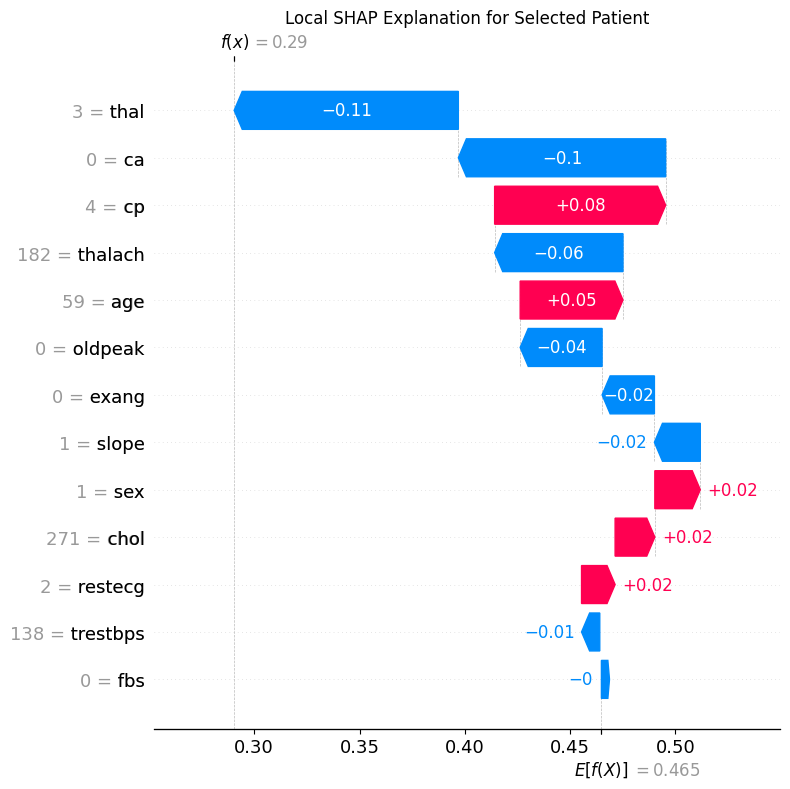

In [ ]:
# Cell 37: SHAP Waterfall Plot for the selected patient

# Create SHAP Explanation object
sample_explanation = shap.Explanation(
    values=shap_values_class1[sample_index],
    base_values=explainer.expected_value[1],
    data=sample.iloc[0].values,
    feature_names=X.columns.tolist()
)

# Generate waterfall plot
plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    sample_explanation,
    max_display=13,
    show=False
)

plt.title("Local SHAP Explanation for Selected Patient")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 38: Select a test patient predicted as heart disease

# Find the first test patient predicted as class 1
positive_indices = np.where(y_pred_rf == 1)[0]

positive_sample_index = positive_indices[0]

positive_sample = X_test_imputed_df.iloc[[positive_sample_index]]
positive_actual_class = y_test.iloc[positive_sample_index]
positive_predicted_class = y_pred_rf[positive_sample_index]
positive_probability = y_prob_rf[positive_sample_index]

print("Selected Heart Disease Prediction")
print("=================================")
print(positive_sample)

print("\nActual Class:", positive_actual_class)
print("Predicted Class:", positive_predicted_class)
print(
    f"Predicted Probability of Heart Disease: "
    f"{positive_probability:.4f}"
)

Selected Heart Disease Prediction
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
1  66.0  1.0  4.0     160.0  228.0  0.0      2.0    138.0    0.0      2.3   

   slope   ca  thal  
1    1.0  0.0   6.0  

Actual Class: 0
Predicted Class: 1
Predicted Probability of Heart Disease: 0.6382


In [ ]:
# Cell 39: SHAP explanation for the selected false-positive patient

positive_sample_shap = shap_values_class1[positive_sample_index]

positive_local_explanation = pd.DataFrame({
    "Feature": X.columns,
    "Feature_Value": positive_sample.iloc[0].values,
    "SHAP_Value": positive_sample_shap
})

positive_local_explanation["Absolute_SHAP"] = np.abs(
    positive_local_explanation["SHAP_Value"]
)

positive_local_explanation = positive_local_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Local SHAP Explanation for False Positive")
print("==========================================")

display(positive_local_explanation)

Local SHAP Explanation for False Positive


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,cp,4.0,0.100623,0.100623
1,ca,0.0,-0.087997,0.087997
2,oldpeak,2.3,0.056001,0.056001
3,thal,6.0,0.050883,0.050883
4,trestbps,160.0,0.047807,0.047807
5,thalach,138.0,0.046157,0.046157
6,slope,1.0,-0.042653,0.042653
7,exang,0.0,-0.028040,0.028040
8,sex,1.0,0.019945,0.019945
9,restecg,2.0,0.012906,0.012906


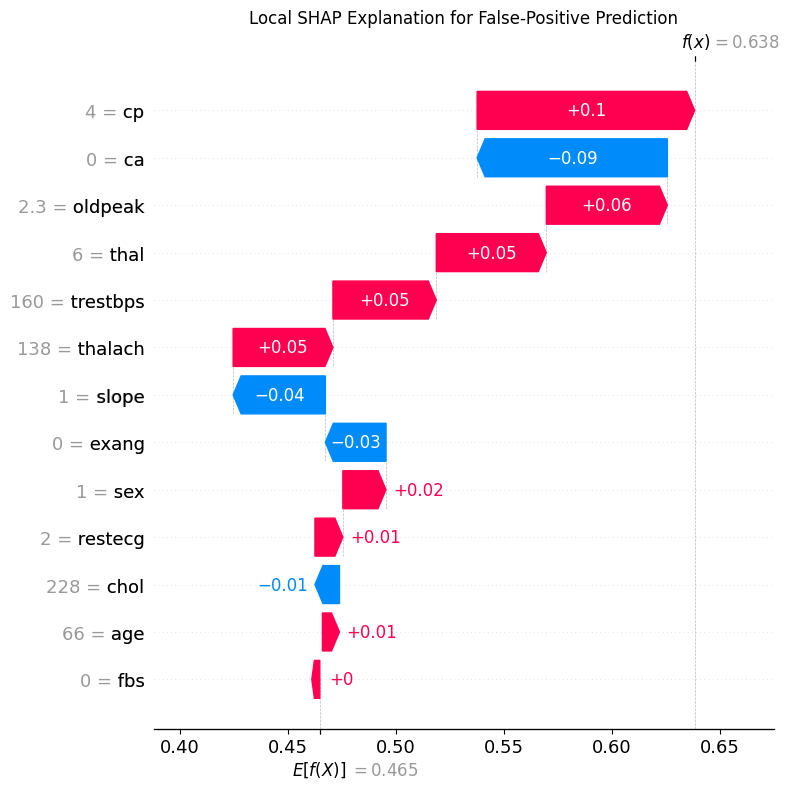

In [ ]:
# Cell 40: SHAP Waterfall Plot for the false-positive patient

positive_sample_explanation = shap.Explanation(
    values=shap_values_class1[positive_sample_index],
    base_values=explainer.expected_value[1],
    data=positive_sample.iloc[0].values,
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    positive_sample_explanation,
    max_display=13,
    show=False
)

plt.title("Local SHAP Explanation for False-Positive Prediction")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 41: Save model and SHAP results

# Save model performance results
results_percent.to_csv(
    "model_performance_results.csv",
    index=False
)

# Save global SHAP feature importance
feature_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

# Save local explanation for the correctly predicted patient
local_explanation.to_csv(
    "local_shap_correct_prediction.csv",
    index=False
)

# Save local explanation for the false-positive patient
positive_local_explanation.to_csv(
    "local_shap_false_positive.csv",
    index=False
)

print("All experimental results saved successfully!")
print("\nFiles created:")
print("1. model_performance_results.csv")
print("2. shap_feature_importance.csv")
print("3. local_shap_correct_prediction.csv")
print("4. local_shap_false_positive.csv")

All experimental results saved successfully!

Files created:
1. model_performance_results.csv
2. shap_feature_importance.csv
3. local_shap_correct_prediction.csv
4. local_shap_false_positive.csv
